# Fresh Eyes on CMIP Data Workshop 2026: Processing CMIP6 data.
## Post-process CMIP6 data after downloading it with intake-ESM
* Plot maximum temperature using Robinson Projection
* Compute and display seasonal mean


### Import all relevant modules

In [8]:
import intake
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import warnings
warnings.filterwarnings("ignore")

### Let's search again the dataset using intake.

In [2]:
cat_url = "https://storage.googleapis.com/cmip6/pangeo-cmip6.json"
col = intake.open_esm_datastore(cat_url)
col

,unique
activity_id,18
institution_id,36
source_id,88
experiment_id,170
member_id,657
table_id,37
variable_id,700
grid_label,10
zstore,514818
dcpp_init_year,61


### We will now build the search query to export to a dataframe.

In [3]:
cat = col.search(
    table_id='Amon',
    institution_id="CSIRO-ARCCSS",
    experiment_id=['historical'],
    source_id='ACCESS-CM2',
    variable_id='tas',
    member_id='r1i1p1f1',
    grid_label='gn')
cat.df

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
0,CMIP,CSIRO-ARCCSS,ACCESS-CM2,historical,r1i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/CSIRO-ARCCSS/ACCESS-CM2/...,<NA>,20191108


### Intake-ESM automatically opens the dataset using xarray.

In [6]:
dset_dict = cat.to_dataset_dict(zarr_kwargs={'consolidated': True},storage_options={"token": "anon"})
list(dset_dict.keys())
ds = dset_dict['CMIP.CSIRO-ARCCSS.ACCESS-CM2.historical.Amon.gn']
ds


--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


<div><progress max="1" value="1"></progress> 100.00% [1/1 00:03&lt;00:00]</div>

<xarray.Dataset> Size: 219MB
Dimensions:         (member_id: 1, dcpp_init_year: 1, time: 1980, lat: 144,
                     lon: 192, bnds: 2)
Coordinates:
  * member_id       (member_id) object 8B 'r1i1p1f1'
  * dcpp_init_year  (dcpp_init_year) float64 8B nan
  * time            (time) datetime64[ns] 16kB 1850-01-16T12:00:00 ... 2014-1...
  * lat             (lat) float64 1kB -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * lon             (lon) float64 2kB 0.9375 2.812 4.688 ... 355.3 357.2 359.1
    lat_bnds        (lat, bnds) float64 2kB dask.array<chunksize=(144, 2), meta=np.ndarray>
    lon_bnds        (lon, bnds) float64 3kB dask.array<chunksize=(192, 2), meta=np.ndarray>
    time_bnds       (time, bnds) datetime64[ns] 32kB dask.array<chunksize=(1980, 2), meta=np.ndarray>
    height          float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    tas             (member_id, dcpp_init_year, time, lat, lon) float32 219MB dask.array<chunksize=(1, 1, 668, 144, 192), meta=np.ndarray>
Attributes: (12/61)
    Conventions:                      CF-1.7 CMIP-6.2
    activity_id:                      CMIP
    branch_method:                    standard
    branch_time_in_child:             0.0
    branch_time_in_parent:            0.0
    cmor_version:                     3.4.0
    ...                               ...
    intake_esm_attrs:variable_id:     tas
    intake_esm_attrs:grid_label:      gn
    intake_esm_attrs:zstore:          gs://cmip6/CMIP6/CMIP/CSIRO-ARCCSS/ACCE...
    intake_esm_attrs:version:         20191108
    intake_esm_attrs:_data_format_:   zarr
    intake_esm_dataset_key:           CMIP.CSIRO-ARCCSS.ACCESS-CM2.historical...

### Maximum temperature in °C

In [37]:
tas_max = ds.tas.max("time") - 273.15

### Let's plot the maximum temperaure using Robinson Projection

Text(0.5, 1.0, 'Maximum Near-Surface Air Temperature')

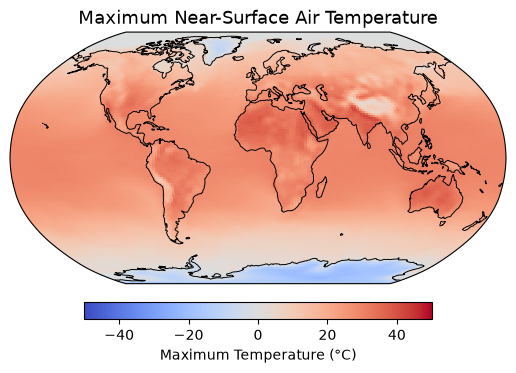

In [39]:
fig, axis = plt.subplots(1, 1, subplot_kw=dict(projection=ccrs.Robinson()))

tas_max.plot(
    ax=axis,
    transform=ccrs.PlateCarree(),
    cmap="coolwarm",
    vmin=-50,
    vmax=50,
    cbar_kwargs={
        "orientation": "horizontal",
        "shrink": 0.7,
        "pad": 0.05,
        "label": "Maximum Temperature (°C)"
    }
)

axis.coastlines(linewidth=0.7)
axis.set_global()
axis.set_title("Maximum Near-Surface Air Temperature", fontsize=13)


### Compute seasonal mean 

In [28]:
seas_mean=ds.tas.groupby("time.season").mean("time")

### Quick display of seasonal means

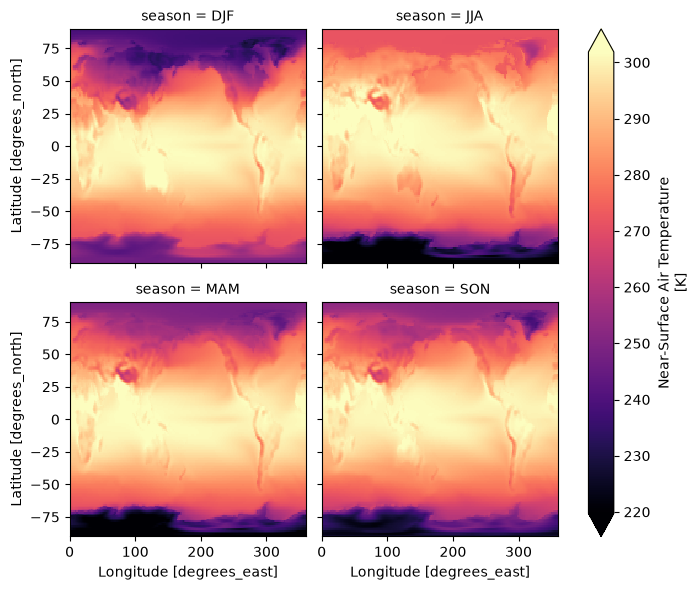

In [29]:
seas_mean.plot(x="lon",y="lat",col="season",col_wrap=2,cmap="magma",robust=True)